# MACHINE LEARNING 2026 - FINAL PROJECT (Option 1)

Course 2025/26: *C. Sun*, *M. Pavan*, *P. Zanuttigh*  

**Group Members:**        
*`Tommaso Dambi ID:2141118`*         
*`Alessandro Costabile ID:2146702`*        
*`Carlo Toffoli ID:2144522`*

## Heart Disease Analysis Using Clustering and Classification
<center>
    <img src="data/dataset-cover.jpg" style = "width: 50%;">
</center>

The dataset labels are the following:

|   id| age   | sex | dataset | cp | trestbps | chol | fbs | restecg | thalch | exang | oldpeak |slope | ca | thal | num |
| :-: | :-:  |  :-: | :-: | :-:| :-: | :-: | :-: | :-: | :-: | :-: | :-: | :-: | :-: | :-: | :-: |
| 1  |  63   | Male | Cleveland | typical angina | 145 | 233 | TRUE | Iv hypertrophy | 150 | FALSE | 2.3 | downsloping | 0 | fixed defect | 0 |
| 2  | 67   | Male | Cleveland | asymptomatic | 160 | 286 | FALSE | Iv hypertrophy | 108 | TRUE | 1.5 | flat | 3 | normal | 1 |
| 3   | 67 | Male | Cleveland | asymptomatic | 120 | 229 | FALSE | Iv hypertrophy | 129 | TRUE | 2.6 | flat | 2 | reversable | 2 |
| 4   | 37| Male | Cleveland | non-anginal | 130 | 250 | FALSE | normal | 187 | FALSE | 3.5 | downsloping | 0 | normal | 3 |

Description of the features:
 - `cp`: chest pain type:
    1. typical angina
    2. atypical angina
    3. non-anginal pain
    4. asymptomatic
 - `trestbps`: resting blood pressure (in mm Hg on admission to the hospital)
 - `chol`: serum cholestoral [mg/dL]
 - `fbs`: fasting blood sugar (True if above 120 mg/dL)
 - `restecg`: resting electrocardiographic results
    1. having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    2. showing probable or definite left ventricular hypertrophy by Estes' criteria
    3. normal
 - `thalch`: maximum heart rate achieved
 - `exang`: exercise induced angina
    1. yes
    2. no
 - `oldpeak`: ST depression induced by exercise relative to rest
 - `slope`: the slope of the peak exercise ST segment
    1. upsloping
    2. flat
    3. downsloping
 - `ca`: number of major vessels (0-3) colored by flouroscopy
 - `thal`: type of defect in blood flow towards heart
    1. fixed defect
    2. reversable
    3. normal
 - `num`: label - severity of the disease from 0 (not present) to 4 (max severity)

Some records lack of data of some features such as `trestbps`, `chol`, `fbs`, `thalch`, `exang`, `oldpeak`, `ca`. This has to be addressed, maybe with clustering?

# Documentation used
- [Numpy](https://numpy.org/doc/stable/reference/index.html#reference)
- [Pandas](https://pandas.pydata.org/docs/reference/index.html#api)
- [Scikit-learn](https://scikit-learn.org/stable/api/index.html)

# ⚠️ OCIO
Il dataset non è incluso per ovvi motivi nel repository github. Scaricalo, estrailo e mettilo nella cartella `/data`. Ricorda di aggiornare il nome del file!
Also: the jupyter server was launched from the upper dir of the project (tdc_fp/..). All the relative imports were done accordingly.

# CODE

## Imports

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tdc_fp.preproc import (
    load_dataset, split_dataset, filter_dataset, 
    encode_feature, standardize, binarize
)
from sklearn.preprocessing import OrdinalEncoder
# from sklearn.model_selection import train_test_split
# from sklearn.cluster import KMeans
# from sklearn.decomposition import PCA
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report, accuracy_score

## 1. Data Preprocessing
All the preprocessing helper functions are defined in `preproc.py`.
As many samples lack the significant `ca` feature we have decided to use just the Cleveland data which provides that feature in almost all the samples.

In [2]:
# TODO: Dropping columns when loading the dataset isn't ideal, move it to another function
# (we will use it to control the number of features)
csv_dataframe = load_dataset('tdc_fp/data/heart_disease_uci.csv', drop_columns=['id']) # tried dropping `ca` because 611 samples were missing it

# print(csv_dataframe.head())

enc = OrdinalEncoder()
dataset = enc.fit_transform(csv_dataframe.to_numpy())
value_map = enc.categories_

# dataset, value_map = encode_feature(csv_dataframe) # Old code - value map is list of list!

# Print the mapped array
print("Dataset is:")
print(dataset.dtype, dataset.shape)

# Deal with nan values BEFORE STANDARDIZATION (issue #2)

# First filter: keep only clean samples from Cleveland
dataset_filtered = filter_dataset(dataset, lambda x: not np.isnan(x[1]).any() and x[1][2] == np.where(value_map[2] == "Cleveland"))
# Second filter: all the samples are from Cleveland, drop that column!
# column 2 is the dataset column
dataset_filtered = filter_dataset(dataset_filtered.T, lambda x: x[0] != 2).T
print("\nFiltered dataset is:")
print(dataset_filtered.dtype, dataset_filtered.shape)

X, Y = split_dataset(dataset_filtered)
print("\nX and Y shapes after filtering:")
print(X.shape, Y.shape)

# Standardization
# TODO: Ask the teacher whether this is fine!
X = standardize(X)

# If you want to take a look to the correlation factor between the single features and the label:
# print(np.corrcoef(X.T[9], Y.ravel()))

# Comment this code if you're trying to do multiclass classification
Y = binarize(Y)

print(f"\nUnique values of Y: {np.unique(Y)}")
print()
print(pd.DataFrame(X).describe().round(3))

Dataset is:
float64 (920, 15)

Filtered dataset is:
float64 (297, 14)

X and Y shapes after filtering:
(297, 13) (297, 1)

Unique values of Y: [0 1]

            0        1        2        3        4        5        6        7   \
count  297.000  297.000  297.000  297.000  297.000  297.000  297.000  297.000   
mean    -0.000   -0.000    0.000    0.000    0.000   -0.000    0.000   -0.000   
std      1.002    1.002    1.002    1.002    1.002    1.002    1.002    1.002   
min     -2.827   -1.447   -0.926   -2.318   -2.108   -0.411   -0.993   -3.127   
25%     -0.724   -1.447   -0.926   -0.701   -0.773   -0.411   -0.993   -0.734   
50%      0.161    0.691    0.042    0.066   -0.061   -0.411    0.909    0.153   
75%      0.715    0.691    1.011    0.576    0.673   -0.411    0.909    0.729   
max      2.486    0.691    1.980    2.534    2.587    2.430    2.811    1.881   

            8        9        10       11       12  
count  297.000  297.000  297.000  297.000  297.000  
mean    -0.000

## 2. Clustering analisys

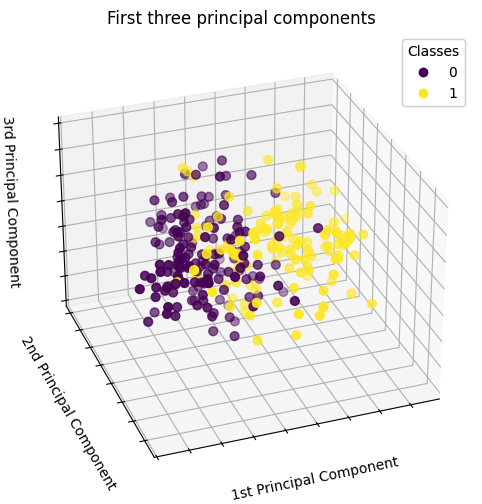

In [15]:
# For what concerns visualization, we need to decompose the data into at most 3 components
# (plus the labels which are represented by the color of the datapoints)

# Sample code
from sklearn.decomposition import PCA

fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

X_reduced = PCA(n_components=3).fit_transform(X)
scatter = ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    X_reduced[:, 2],
    c=pd.Series(Y.ravel()),
    s=40,
)

ax.set(
    title="First three principal components",
    xlabel="1st Principal Component",
    ylabel="2nd Principal Component",
    zlabel="3rd Principal Component",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

# Add a legend
legend1 = ax.legend(
    scatter.legend_elements()[0],
    np.unique(Y).tolist(),
    loc="upper right",
    title="Classes",
)
ax.add_artist(legend1)

plt.show()
